# ETKDG Conformer Embedding: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 3 of the nvMolKit acceleration series.**

[ETKDG](https://www.rdkit.org/docs/source/rdkit.Chem.rdDistGeom.html) is RDKit's distance-geometry method for
generating 3D conformers. Building a conformer library for a screening set means embedding *many molecules ×
many conformers each* — a large, independent batch that nvMolKit runs across the GPU.

This notebook compares:

- **RDKit (CPU)** — `rdDistGeom.EmbedMultipleConfs(mol, numConfs, params)` per molecule (single- and multi-threaded).
- **nvMolKit (GPU)** — `nvmolkit.embedMolecules.EmbedMolecules(mols, params, confsPerMolecule=...)`, batched.

**Parity:** nvMolKit's ETKDG only supports random-coordinate initialization, so for an apples-to-apples
comparison we set `useRandomCoords=True` on the RDKit baseline too (same `randomSeed`).

**Important:** ETKDG is *stochastic*. The two implementations will not produce bit-identical coordinates, so we
do not check for equality. Instead we use RDKit's MMFF energy as a neutral referee to confirm nvMolKit generates
conformer ensembles of **comparable quality**, then we measure throughput.

> Run from this `examples/tutorials/` directory so `./nvmolkit` in the repo root doesn't shadow the install.


## 1. Setup and GPU check

In [1]:
import copy
import time

import numpy as np
import pandas as pd
import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, MolFromSmiles, AddHs
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.embedMolecules import EmbedMolecules
from nvmolkit.types import HardwareOptions

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 10       # conformers generated per molecule (more confs => bigger GPU batch)
N_CPU_THREADS = 16
RANDOM_SEED = 42
SIZES = [5, 10, 20, 40]  # number of molecules (small set keeps random-coords ETKDG tractable)
MIN_HEAVY, MAX_HEAVY = 15, 30   # keep normal-sized molecules; huge flexible ones stall random-coords ETKDG
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, cpu_threads={N_CPU_THREADS}, sizes={SIZES}")

confs/mol=10, cpu_threads=16, sizes=[5, 10, 20, 40]


## 3. Load molecules (with explicit hydrogens)

ETKDG needs explicit hydrogens for sensible geometries, so we `AddHs` after parsing. We keep normal-sized
molecules (`MIN_HEAVY`–`MAX_HEAVY` heavy atoms): with **random-coordinate** initialization (used by both
backends here), very large flexible molecules can take many seconds *each* on the CPU and would dominate the
run. We strip any conformers so every timed run starts clean.

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=5000).iloc[:, 0].tolist()
mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None:
        continue
    if MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY:
        mols_all.append(AddHs(m))
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules ({MIN_HEAVY}-{MAX_HEAVY} heavy atoms, Hs added); sweep sizes = {SIZES}")

Prepared 40 molecules (15-30 heavy atoms, Hs added); sweep sizes = [5, 10, 20, 40]


## 4. Define the two backends

Each call embeds into *fresh copies* so the backends never share state and repeated runs are independent. Both
return the list of molecules with `CONFS_PER_MOL` conformers each.

In [4]:
def fresh_copies(mols):
    out = []
    for m in mols:
        m2 = copy.deepcopy(m)
        m2.RemoveAllConformers()
        out.append(m2)
    return out


def make_params(num_threads=1):
    p = ETKDGv3()
    p.randomSeed = RANDOM_SEED
    p.useRandomCoords = True          # required by nvMolKit; set on both for parity
    p.numThreads = num_threads
    return p


def rdkit_embed(mols, num_threads=1):
    p = make_params(num_threads)
    for m in mols:
        EmbedMultipleConfs(m, numConfs=CONFS_PER_MOL, params=p)
    return mols


def nvmolkit_embed(mols):
    EmbedMolecules(
        molecules=mols,
        params=make_params(),
        confsPerMolecule=CONFS_PER_MOL,
        maxIterations=-1,
        hardwareOptions=HardwareOptions(preprocessingThreads=N_CPU_THREADS),
    )
    torch.cuda.synchronize()
    return mols

## 5. Quality check (MMFF energy as a neutral referee)

Since coordinates differ run-to-run, we judge *quality* instead of equality: compute the MMFF energy of every
generated conformer with RDKit (the same scorer for both backends) and compare the distributions. Comparable
energy distributions mean nvMolKit produces conformers of similar physical quality.

In [5]:
def mmff_energies(mols):
    energies = []
    for m in mols:
        if not AllChem.MMFFHasAllMoleculeParams(m):
            continue
        props = AllChem.MMFFGetMoleculeProperties(m)
        for conf in m.GetConformers():
            ff = AllChem.MMFFGetMoleculeForceField(m, props, confId=conf.GetId())
            if ff is not None:
                energies.append(ff.CalcEnergy())
    return np.array(energies)


sample = mols_all[:max(SIZES)]
rd_sample = rdkit_embed(fresh_copies(sample), num_threads=N_CPU_THREADS)
nv_sample = nvmolkit_embed(fresh_copies(sample))

rd_conf_counts = [m.GetNumConformers() for m in rd_sample]
nv_conf_counts = [m.GetNumConformers() for m in nv_sample]
print(f"conformers/mol  RDKit: min {min(rd_conf_counts)} max {max(rd_conf_counts)} | "
      f"nvMolKit: min {min(nv_conf_counts)} max {max(nv_conf_counts)}")

rd_e = mmff_energies(rd_sample)
nv_e = mmff_energies(nv_sample)
print(f"MMFF energy (kcal/mol)  RDKit:    n={len(rd_e):4d}  mean {rd_e.mean():8.2f}  median {np.median(rd_e):8.2f}")
print(f"MMFF energy (kcal/mol)  nvMolKit: n={len(nv_e):4d}  mean {nv_e.mean():8.2f}  median {np.median(nv_e):8.2f}")

conformers/mol  RDKit: min 10 max 10 | nvMolKit: min 10 max 10


MMFF energy (kcal/mol)  RDKit:    n= 380  mean    94.74  median   103.87
MMFF energy (kcal/mol)  nvMolKit: n= 380  mean    93.16  median   106.17


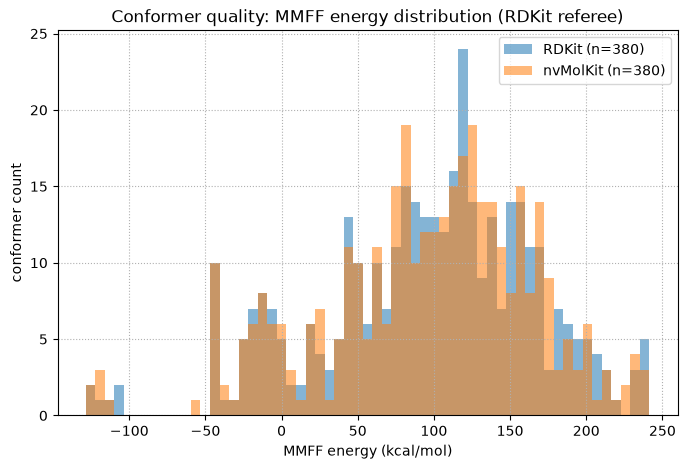

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
lo, hi = np.percentile(np.concatenate([rd_e, nv_e]), [1, 99])
bins = np.linspace(lo, hi, 60)
plt.hist(rd_e, bins=bins, alpha=0.55, label=f"RDKit (n={len(rd_e)})")
plt.hist(nv_e, bins=bins, alpha=0.55, label=f"nvMolKit (n={len(nv_e)})")
plt.xlabel("MMFF energy (kcal/mol)")
plt.ylabel("conformer count")
plt.title("Conformer quality: MMFF energy distribution (RDKit referee)")
plt.legend(); plt.grid(True, ls=":")
plt.show()

## 6. Warm up the GPU

In [7]:
nvmolkit_embed(fresh_copies(mols_all[:32]))
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

Embedding is expensive and stochastic, so we time a single run per configuration (results are dominated by the
work, not timer noise). We sweep the number of molecules and record wall-clock seconds and throughput.

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(lambda m: rdkit_embed(m, num_threads=1), fresh_copies(base))
    t_rdN = timed(lambda m: rdkit_embed(m, num_threads=N_CPU_THREADS), fresh_copies(base))
    t_gpu = timed(nvmolkit_embed, fresh_copies(base))
    total_confs = n * CONFS_PER_MOL
    rows.append({
        "n_mols": n,
        "total_confs": total_confs,
        "rdkit_1thread_s": t_rd1,
        f"rdkit_{N_CPU_THREADS}thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_confs_per_s": total_confs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        f"speedup_vs_{N_CPU_THREADS}thread": t_rdN / t_gpu,
    })
    print(f"n={n:5d} | confs={total_confs:6d} | RDKit-1t {t_rd1:8.2f}s | "
          f"RDKit-{N_CPU_THREADS}t {t_rdN:7.2f}s | nvMolKit {t_gpu:6.2f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=    5 | confs=    50 | RDKit-1t     1.21s | RDKit-16t    0.24s | nvMolKit   0.24s | speedup    5.1x /   1.0x


n=   10 | confs=   100 | RDKit-1t     3.07s | RDKit-16t    0.61s | nvMolKit   0.26s | speedup   11.8x /   2.3x


n=   20 | confs=   200 | RDKit-1t     7.10s | RDKit-16t    1.44s | nvMolKit   0.32s | speedup   22.1x /   4.5x


n=   40 | confs=   400 | RDKit-1t    14.31s | RDKit-16t    2.80s | nvMolKit   0.45s | speedup   31.7x /   6.2x


,n_mols,total_confs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_confs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,5,50,1.208948,0.240662,0.238655,209.507394,5.065672,1.008408
1,10,100,3.065888,0.605388,0.259439,385.446630,11.817360,2.333449
2,20,200,7.103639,1.443050,0.322085,620.954719,22.055192,4.480345
3,40,400,14.314786,2.800870,0.451312,886.305136,31.718171,6.206063


## 8. Plot: runtime and speedup vs number of molecules

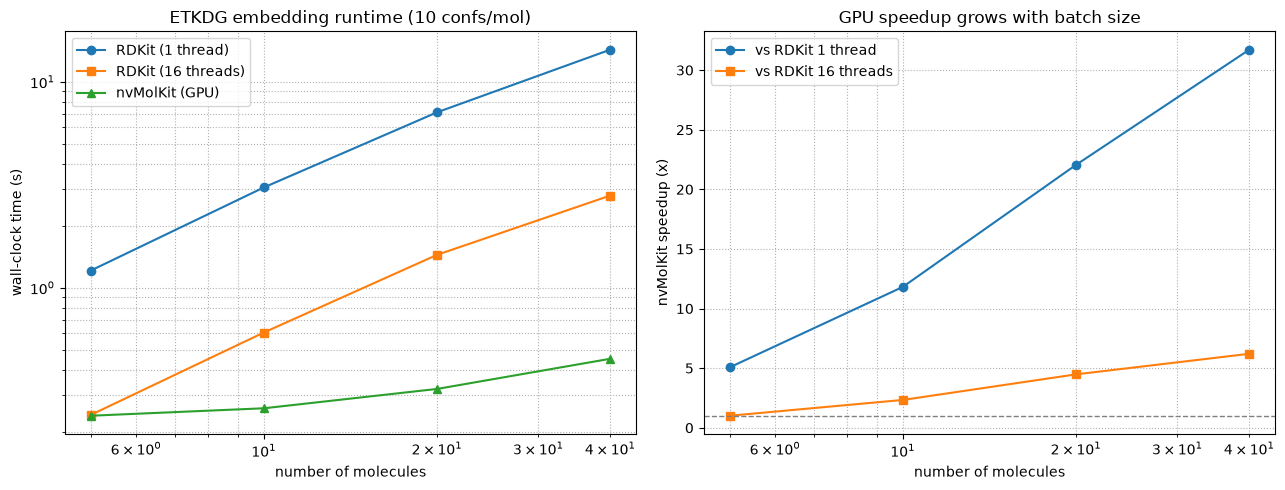

In [9]:
col_rdN = f"rdkit_{N_CPU_THREADS}thread_s"
col_spN = f"speedup_vs_{N_CPU_THREADS}thread"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df[col_rdN], "s-", label=f"RDKit ({N_CPU_THREADS} threads)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"ETKDG embedding runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df[col_spN], "s-", label=f"vs RDKit {N_CPU_THREADS} threads")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

## 9. Takeaways

- **Comparable quality.** nvMolKit's ETKDG conformers land in the same MMFF-energy distribution as RDKit's, so
  the GPU ensemble is physically equivalent even though individual coordinates differ (ETKDG is stochastic).
- **Batching wins.** The more molecules embedded together, the better the GPU stays saturated and the higher the
  speedup — ideal for building conformer libraries for screening.
- **In-place, RDKit-native.** `EmbedMolecules` writes conformers straight back into the input `Mol` objects, so
  it drops into an existing RDKit pipeline. (`output=CoordinateOutput.DEVICE` keeps coordinates on the GPU for
  chaining into MMFF/UFF — see Tutorial 4.)
- **Caveats.** `params.useRandomCoords` must be `True`; a few niche `EmbedParameters` options are unsupported.

**Next:** Tutorial 4 takes these conformers into GPU-accelerated MMFF94 optimization.